In [6]:
import h5py
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [7]:
matFilename1 = './data/2018-08-28_batchdata_updated_struct_errorcorrect.mat'
matFilename2 = './data/2018-09-02_batchdata_updated_struct_errorcorrect.mat'
matFilename3 = './data/2018-09-06_batchdata_updated_struct_errorcorrect.mat'
matFilename4 = './data/2018-09-10_batchdata_updated_struct_errorcorrect.mat'
matFilename5 = './data/2018-04-12_batchdata_updated_struct_errorcorrect.mat'


f1 = h5py.File(matFilename1)
f2 = h5py.File(matFilename2)
f3 = h5py.File(matFilename3)
f4 = h5py.File(matFilename4)
f5 = h5py.File(matFilename5)

batch1 = f1['batch']
batch2 = f2['batch']
batch3 = f3['batch']
batch4 = f4['batch']
batch5 = f5['batch']


In [8]:
print("keys")
print(list(f1.keys()))
print(list(f2.keys()))
print(list(f3.keys()))
print(list(f4.keys()))
print(list(f5.keys()))
print("")

print("keys for batch")
print(list(f1['batch'].keys()))
print(list(f2['batch'].keys()))
print(list(f3['batch'].keys()))
print(list(f4['batch'].keys()))
print(list(f5['batch'].keys()))


keys
['#refs#', '#subsystem#', 'batch', 'batch_date']
['#refs#', '#subsystem#', 'batch', 'batch_date']
['#refs#', '#subsystem#', 'batch', 'batch_date']
['#refs#', '#subsystem#', 'batch', 'batch_date']
['#refs#', '#subsystem#', 'batch', 'batch_date']

keys for batch
['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [9]:

def createBatDict(numCells, f, batchNum):
    batDict = {}
    for i in range(numCells):
        raw = f[f['batch']['cycle_life'][i, 0]][()]
        print(f"cell {i}: dtype={raw.dtype}, shape={raw.shape}, value={raw}")
        cl = raw.item()
        policy = f[f['batch']['policy_readable'][i, 0]][()].tobytes()[::2].decode()
                
        summaryRef = f[f['batch']['summary'][i, 0]]
        summaryIR = np.hstack(summaryRef['IR'][0, :].tolist())
        summaryQC = np.hstack(summaryRef['QCharge'][0, :].tolist())
        summaryQD = np.hstack(summaryRef['QDischarge'][0, :].tolist())
        summaryTA = np.hstack(summaryRef['Tavg'][0, :].tolist())
        summaryTM = np.hstack(summaryRef['Tmin'][0, :].tolist())
        summaryTX = np.hstack(summaryRef['Tmax'][0, :].tolist())
        summaryCT = np.hstack(summaryRef['chargetime'][0, :].tolist())
        summaryCY = np.hstack(summaryRef['cycle'][0, :].tolist())
        summary = {
            'IR': summaryIR, 'QC': summaryQC, 'QD': summaryQD,
            'Tavg': summaryTA, 'Tmin': summaryTM, 'Tmax': summaryTX,
            'chargetime': summaryCT, 'cycle': summaryCY
        }

        cycles = f[f['batch']['cycles'][i, 0]]
        cycleDict = {}
        for j in range(cycles['I'].shape[0]):
            I     = np.hstack(f[cycles['I'][j, 0]][()])
            Qc    = np.hstack(f[cycles['Qc'][j, 0]][()])
            Qd    = np.hstack(f[cycles['Qd'][j, 0]][()])
            Qdlin = np.hstack(f[cycles['Qdlin'][j, 0]][()])
            T     = np.hstack(f[cycles['T'][j, 0]][()])
            Tdlin = np.hstack(f[cycles['Tdlin'][j, 0]][()])
            V     = np.hstack(f[cycles['V'][j, 0]][()])
            dQdV  = np.hstack(f[cycles['discharge_dQdV'][j, 0]][()])
            t     = np.hstack(f[cycles['t'][j, 0]][()])
            cycleDict[str(j)] = {
                'I': I, 'Qc': Qc, 'Qd': Qd, 'Qdlin': Qdlin,
                'T': T, 'Tdlin': Tdlin, 'V': V, 'dQdV': dQdV, 't': t
            }

        batDict[f'b{batchNum}c{i}'] = {
            'cycle_life': cl,
            'charge_policy': policy,
            'summary': summary,
            'cycles': cycleDict
        }
    return batDict


In [10]:
numCells1 = f1['batch']['summary'].shape[0]
numCells2 = f2['batch']['summary'].shape[0]
numCells3 = f3['batch']['summary'].shape[0]
numCells4 = f4['batch']['summary'].shape[0]
numCells5 = f5['batch']['summary'].shape[0]

batDict1 = createBatDict(numCells1, f1, 1)
batDict2 = createBatDict(numCells2, f2, 2)
batDict3 = createBatDict(numCells3, f3, 3)
batDict4 = createBatDict(numCells4, f4, 4)
batDict5 = createBatDict(numCells5, f5, 5)

cell 0: dtype=float64, shape=(1, 1), value=[[nan]]
cell 1: dtype=float64, shape=(1, 1), value=[[nan]]
cell 2: dtype=float64, shape=(1, 1), value=[[nan]]
cell 3: dtype=float64, shape=(1, 1), value=[[nan]]
cell 4: dtype=float64, shape=(1, 1), value=[[nan]]
cell 5: dtype=float64, shape=(1, 1), value=[[nan]]
cell 6: dtype=float64, shape=(1, 1), value=[[nan]]
cell 7: dtype=float64, shape=(1, 1), value=[[nan]]
cell 8: dtype=float64, shape=(1, 1), value=[[nan]]
cell 9: dtype=float64, shape=(1, 1), value=[[nan]]
cell 10: dtype=float64, shape=(1, 1), value=[[nan]]
cell 11: dtype=float64, shape=(1, 1), value=[[nan]]
cell 12: dtype=float64, shape=(1, 1), value=[[nan]]
cell 13: dtype=float64, shape=(1, 1), value=[[nan]]
cell 14: dtype=float64, shape=(1, 1), value=[[nan]]
cell 15: dtype=float64, shape=(1, 1), value=[[nan]]
cell 16: dtype=float64, shape=(1, 1), value=[[nan]]
cell 17: dtype=float64, shape=(1, 1), value=[[nan]]
cell 18: dtype=float64, shape=(1, 1), value=[[nan]]
cell 19: dtype=float64

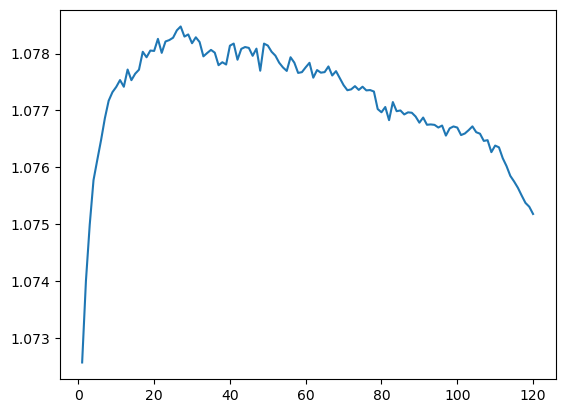

In [11]:
plt.plot(batDict1['b1c43']['summary']['cycle'], batDict1['b1c43']['summary']['QD'])

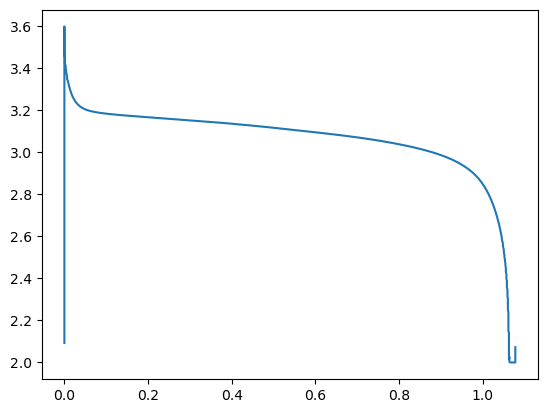

In [12]:
plt.plot(batDict1['b1c43']['cycles']['10']['Qd'], batDict1['b1c43']['cycles']['10']['V'])

In [13]:
with open('./data/batch1.pkl', 'wb') as fp:
    pickle.dump(batDict1, fp)

with open('./data/batch2.pkl', 'wb') as fp:
    pickle.dump(batDict2, fp)

with open('./data/batch3.pkl', 'wb') as fp:
    pickle.dump(batDict3, fp)

with open('./data/batch4.pkl', 'wb') as fp:
    pickle.dump(batDict4, fp)

with open('./data/batch5.pkl', 'wb') as fp:
    pickle.dump(batDict5, fp)